# UKCI Threshold Detector

Detects extreme and compound events across UKCI (UKCP for now) data for a chosen UK region.   
The ensemble gives a **range of projections** rather than a single answer, reflecting model uncertainty.Single ensemble members shouldn't be taken as truth, all members represent equally (is equally correct?) plausible projections. For this reason, ensemble means aren't a realistic 'middle of the road' projection of future climate change, as it can wash out variability.   
Not all members needs to agree on a trend for it to be considered valid, even a couple of members exhibiting a behaviour change (e.g.: increase in drought conditions by 2040) can be considered a significant likelihood of occuring. 

## What to do

**You only need to edit Cell 2.** All other cells run automatically from those settings. Work through the cells in order (Run All, or Shift+Enter cell by cell).

## Detection modes

The notebook supports three modes, controlled by the parameters in Cell 2:

| Mode | When to use | Key settings |
|---|---|---|
| **Single-variable** | One variable, one threshold | Set `THRESHOLD_2 = None` |
| **Bivariate: sequential** | Two variables that occur within a few days of each other (e.g. a dry spell *followed by* extreme rainfall) | Set `THRESHOLD_2`, `COMPOUND_MODE = 'sequential'` |
| **Bivariate: co-occurring** | Two variables that are simultaneously extreme (e.g. a heat extreme *during* a drought) | Set `THRESHOLD_2`, `COMPOUND_MODE = 'co-occurring'` |

In **sequential** mode a compound event is a cluster of extreme days drawn from *either* variable, where no two consecutive extreme days (from either series) are more than `DELT` days apart, and the cluster contains at least one extreme day from *each* variable.

In **co-occurring** mode a compound event requires at least one day where *both* variables are simultaneously extreme. Adjacent coincident days within `DELT` of each other are merged into a single event.

---

## Parameter reference

### Data sources
| Parameter | Description |
|---|---|
| `BASE_DIR` | Root directory that contains per-region sub-folders for **Variable 1**. |
| `FILENAME_PATTERN` | Filename template for Variable 1. Use `{ensemble}` and `{region}` as placeholders, e.g. `'p110{ensemble}_{region}.nc'`. |
| `BASE_DIR_2` | Root directory for **Variable 2**. Set to `None` to load both variables from the same files as Variable 1. |
| `FILENAME_PATTERN_2` | Filename template for Variable 2. Set to `None` to use the same template as Variable 1. |

### Domain
| Parameter | Description |
|---|---|
| `REGION` | The UK region to analyse in Steps 2–4. Must match a sub-folder name inside `BASE_DIR`. |
| `ENSEMBLES` | List of ensemble member IDs to process. |
| `ALL_REGIONS` | Full list of UK regions used in the UK-wide (Step 5) and regional (Step 6) plots. |

### Season
| Parameter | Description |
|---|---|
| `LOWER_MONTH` | First month of the season to extract (inclusive, 1–12). |
| `HIGHER_MONTH` | Last month of the season to extract (inclusive, 1–12). Default `6–9` = JJAS (summer). |

### Variable 1 — threshold
| Parameter | Description |
|---|---|
| `THRESHOLD_1` | The threshold value that defines an extreme event for Variable 1. Units should match the data (e.g. mm/hr, °C). |
| `DIRECTION_1` | `'above'` flags values *greater than* the threshold (e.g. heavy rain, heat). `'below'` flags values *less than* the threshold (e.g. drought, cold). |
| `N_CONSECUTIVE_1` | Window length in days for one flag. `1` means any single exceedance counts; increase for spells (heatwaves, droughts). |
| `MIN_DAYS_1` | Tolerance: minimum extreme days inside the `N`-day window (`None` = all `N`). E.g. `N=20, MIN_DAYS=19` = a 20-day drought with ≥ 19 dry days. |
| `FLAG_1` | What one flag *means* when `N > 1`: `'last'` / `'first'` = one flag per whole spell (on its last / first day); `'all'` = re-mark the extreme days, so counts stay in days. Irrelevant when `N = 1`. **See the flowchart and worked example in the next section.** |

### Variable 2 — threshold (bivariate only)
These work identically to the Variable 1 settings above, but are applied to the second timeseries. Set `THRESHOLD_2 = None` to run in single-variable mode.

| Parameter | Description |
|---|---|
| `THRESHOLD_2` | Threshold for Variable 2. `None` disables bivariate detection. |
| `DIRECTION_2` | `'above'` or `'below'`, as above. |
| `N_CONSECUTIVE_2` | Consecutive days required for Variable 2. |

### Compound detection
These settings apply to all three modes.

| Parameter | Description |
|---|---|
| `COMPOUND_MODE` | `'sequential'` or `'co-occurring'`. Only relevant when `THRESHOLD_2` is set. |
| `DELT` | Maximum gap in days between consecutive extreme days (from either variable in bivariate mode) that still allows them to be grouped into a single compound event. Larger values merge more spread-out clusters. |
| `MIN_DURATION` | Minimum number of **flags** per cluster to count as a compound event. What a flag means depends on `FLAG_*`: with `N=1` or `'all'` it's extreme days; with `'last'`/`'first'` it's whole spells. Note: in single-variable mode an isolated flag is never an event, even with `MIN_DURATION=1`. |
| `TAU` | Minimum linkage lag (days), must be ≥ 1. Flagged days link when their gap `g` satisfies `TAU ≤ g ≤ TAU + DELT` — so the **maximum** linkage gap is `TAU + DELT` (5 days with the defaults). |

### Plotting
| Parameter | Description |
|---|---|
| `CMAP` | Matplotlib colormap name used in the Hovmöller plots (e.g. `'Blues'`, `'YlOrRd'`). More examples here: https://matplotlib.org/stable/users/explain/colors/colormaps.html |
| `ROLLING_WINDOW` | Window size (years) for the rolling mean in the ensemble-spread plot (Step 3). |
| `DATA_START_YEAR` | Calendar year that index 0 of the loaded timeseries corresponds to. Used to assign a `year` label to each detected event. |

---

## Output

Each step produces a different view of the same compound-event signal:

- **Step 1** — loads the raw timeseries for every ensemble member.
- **Step 2** — flags extreme days and detects compound events for every member.
- **Step 3** — plots the ensemble *spread* (mean ± min/max band) of compound-event counts per year.
- **Step 4** — Hovmöller plot: every ensemble member × every year for the chosen region.
- **Step 5** — UK-wide Hovmöller: a day is counted if *any* region had a compound event on that day.
- **Step 6** — Regional Hovmöller: ensemble-mean compound extreme days per region per year.


## Example use cases

The parameter cell below drives all three detection modes. Copy one of these
configurations into it as a starting point. Each example states what the
flag means and what gets tracked, because that is what `FLAG_*`,
`N_CONSECUTIVE_*` and `MIN_DURATION*` jointly decide. I have also made a flowchart, 
so work it to make a better decision.

**1. Single-variable: clustered extreme-rain days **

*Unit tracked: individual extreme-rain days. `FLAG_1` is irrelevant because `N=1`.*
```
THRESHOLD_1=20, DIRECTION_1='above', N_CONSECUTIVE_1=1, MIN_DAYS_1=None
THRESHOLD_2=None                      # single-variable mode
MIN_DURATION=2                        # >= 2 extreme days close together
SEASON_START, SEASON_LENGTH = 6, 4    # June-September
```

**2. Single-variable: clustering of heatwaves**

*Unit tracked: whole 3-day heatwaves — one flag per wave (`FLAG_1='last'`),
so `MIN_DURATION=2` means "≥ 2 heatwaves close together" and
`n_extreme_cases` counts waves, **not** hot days.*
```
FILENAME_PATTERN='tasmax{ensemble}_{region}.nc'  # tbd
THRESHOLD_1=28, DIRECTION_1='above', N_CONSECUTIVE_1=3, FLAG_1='last'
THRESHOLD_2=None, MIN_DURATION=2
```
*Variant — day-resolved heatwave durations: set `FLAG_1='all'` and counts
switch to hot days inside waves; `MIN_DURATION` then means "≥ that many hot
days". Note two back-to-back waves link under `'last'` only if
`N ≤ TAU + DELT` (3 ≤ 5 with the defaults).*

**3. Sequential: drought then downpour**

*"A 20-day drought with at least 19 dry days, followed by ≥ 3 days of
rainfall." `FLAG_1='first'` puts the drought flag on its ONSET so its
position vs the rain days is correctly positioned; with `'last'` the flag would land
up to 20 days later (possibly on a wet day, since `MIN_DAYS < N`).*
```
THRESHOLD_1=1,  DIRECTION_1='below', N_CONSECUTIVE_1=20, MIN_DAYS_1=19, FLAG_1='first'
THRESHOLD_2=20,  DIRECTION_2='above', N_CONSECUTIVE_2=1,  MIN_DAYS_2=None  # rain days, daily
COMPOUND_MODE='sequential'
MIN_DURATION_1=1, MIN_DURATION_2=3    # >= 1 drought flag AND >= 3 rain days per event
```
(Equivalent alternative: `N_CONSECUTIVE_2=3, FLAG_2='last'` to demand 3
*consecutive* rain days as one flag, with `MIN_DURATION_2=1`.)

**4. Sequential, two files: dry spell then hot spell**

*Unit tracked per variable: whole spells (one flag each). Both use
`'first'` so the event ordering (dry onset before hot onset) is legible in
the flag positions.*
```
BASE_DIR_2='/path/to/tasmax', FILENAME_PATTERN_2='tasmax{ensemble}_{region}.nc'
THRESHOLD_1=1,  DIRECTION_1='below', N_CONSECUTIVE_1=10, FLAG_1='first'  # 10-day dry spell
THRESHOLD_2=28, DIRECTION_2='above', N_CONSECUTIVE_2=3,  FLAG_2='first'  # 3-day hot spell
COMPOUND_MODE='sequential', MIN_DURATION_1=1, MIN_DURATION_2=1
```

**5. Co-occurring: compound hot-and-dry days**

*Unit tracked: days where BOTH conditions hold. Keep `N=1` on both — the
coincidence test is per-day, so pre-bundling into spells would make
"same-day" mean "same flag position", which is probs not what you want.*
```
BASE_DIR_2='/path/to/tasmax', FILENAME_PATTERN_2='tasmax{ensemble}_{region}.nc'
THRESHOLD_1=1,  DIRECTION_1='below', N_CONSECUTIVE_1=1    # dry day
THRESHOLD_2=28, DIRECTION_2='above', N_CONSECUTIVE_2=1    # hot day
COMPOUND_MODE='co-occurring'
MIN_DURATION=2                        # >= 2 hot-AND-dry days per event
```

**6. Wrapped season: winter storm clustering (October through February)**
```
SEASON_START, SEASON_LENGTH = 10, 5   # Oct-Feb, wraps the calendar year;
                                      # season-year is labelled by the START year
THRESHOLD_1=20, DIRECTION_1='above', N_CONSECUTIVE_1=1, THRESHOLD_2=None
```


## Which `flag` should I use? — decision flowchart

`flag` only matters when `N_CONSECUTIVE > 1`. It decides what one flag in
the binary series *means*, and therefore what everything downstream counts:

| | one flag = | `n_extreme_cases` counts | `MIN_DURATION=2` means |
|---|---|---|---|
| `'last'` (default) | one whole N-day spell, marked on its **last** day | spells | ≥ 2 spells close together |
| `'first'` | one whole N-day spell, marked on its **first** day | spells | ≥ 2 spells close together |
| `'all'` | one extreme **day** inside a qualifying spell | extreme days | ≥ 2 extreme days close together |

![flag decision flowchart](../docs/flag_decision_flowchart.svg)

Full guide with a worked example and all the verified pitfalls:
[`put/this/in`](filepaht/here).
The cell below builds the comparison table **on a toy series** — swap in
your own data and settings to see exactly what each option would flag.


In [ ]:
#set file paths for both variables here.
# var2 defaults to None, which means it re-uses Variable 1's values.
BASE_DIR           = '/home/users/elena.dauster/Documents/python/CoinCalc/data_for_ECA'
FILENAME_PATTERN   = 'p110{ensemble}_{region}.nc'    # var1 filename template
BASE_DIR_2         = None    # e.g. '/path/to/temperature/data' — None = same as BASE_DIR
FILENAME_PATTERN_2 = None    # e.g. 'tasmax{ensemble}_{region}.nc' — None = same as FILENAME_PATTERN

REGION = 'South_East_England'   # choose one region

ENSEMBLES = ['0000','1113','1554','1649','1843','1935','2123','2242','2305','2335','2491','2868']

# All UK regions (used for the UK, used in Step 5)
ALL_REGIONS = [
    'East_Midlands', 'East_Scotland', 'East_of_England', 'North_East_England',
    'North_Scotland', 'North_West_England', 'Northern_Ireland', 'South_East_England',
    'South_West_England', 'Wales', 'West_Midlands', 'West_Scotland', 'Yorkshire_and_Humber',]

# --- Season (modular) ---
# Start month + duration in months, wrapping the calendar year if needed:
#   (6, 4)  = June -> September (JJAS)
#   (8, 2)  = August -> September
#   (10, 5) = October -> February (wraps; the season-year label is the
#             year the season STARTED in, so Oct 1980 - Feb 1981 = 1980)
SEASON_START  = 5
SEASON_LENGTH = 5

# --- Variable 1 event definition ---
THRESHOLD_1     = 20          # threshold
DIRECTION_1     = 'above'    # 'above' or 'below' the threshold
N_CONSECUTIVE_1 = 1          # window length (days) to flag one event
MIN_DAYS_1      = 1          # min extreme days within the window
                             # (None = all N required; e.g. N=20, MIN_DAYS=19
                             #  = a 20-day drought with >= 19 dry days)
FLAG_1          = 'all'     # what one flag means when N > 1:
                             #  'last'/'first' = one flag per whole spell
                             #  (on its last/first day) -> counts are SPELLS;
                             #  'all' = re-mark the extreme days -> counts
                             #  stay in DAYS. Irrelevant when N = 1.
                             #  NOTE: 'all' flags consecutive days; their gap
                             #  is 0 which is < TAU=1, so they never link and
                             #  produce no events. Use 'last' for heatwaves.
                             #  See the flowchart in the docs.

# --- var 2 event definition (set THRESHOLD_2 = None for single-variable mode) ---
# File paths for Variable 2 are set above (BASE_DIR_2 / FILENAME_PATTERN_2).
THRESHOLD_2     = None          # set to None to disable two-variable modes
DIRECTION_2     = 'above'    # 'above' or 'below'
N_CONSECUTIVE_2 = 1        # window length (days) for variable 2
MIN_DAYS_2      = None       # tolerance for variable 2 (None = all N required)
FLAG_2          = 'last'     # as FLAG_1, for variable 2

# --- Compound mode (two-variable only) ---
# 'sequential'   : extremes from both variables within the linkage window of
#                  each other (e.g. dry spell then extreme rain)
# 'co-occurring' : both variables extreme on the same day(s)
#                  (e.g. heat + drought)
COMPOUND_MODE = 'sequential'

# --- Compound detection ---
# Flagged days link when their gap g satisfies TAU <= g <= TAU + DELT within
# one season — the MAX linkage gap is TAU + DELT days, and events never pair
# across a season boundary.
DELT = 4                     # ECA coincidence window
TAU  = 1                     # ECA minimum lag (must be >= 1)

# Minimum flagged days per compound event — consistent across modes:
MIN_DURATION   = 2          # single-variable: >= 2 heatwave spells close together;
                             # co-occurring: coincident (both-extreme) days.
                             # NOTE: in single-variable mode an isolated flag
                             # (one heatwave with no neighbour within TAU+DELT days)
                             # is NEVER an event, even with MIN_DURATION=1.
MIN_DURATION_1 = 1           # sequential: min variable-1 flags per event
MIN_DURATION_2 = 1           # sequential: min variable-2 flags per event

# --- MSLP composites (Step 7) ---
# The composite field should be loaded on the FULL calendar year, not
# season-extracted: negative lags need the days BEFORE the season starts.
#
# load_field_ensemble substitutes {ensemble} into MSLP_PATTERN only.
# MSLP_BASE_DIR must be the common root (no {ensemble} in it).
# The ensemble-specific sub-path goes into MSLP_PATTERN instead.
# Use * for the decade suffix — iris.load handles the glob and merges the
# decade files into a single timeseries automatically.
MSLP_BASE_DIR      = '/data/users/qump1/data/qump_hadgem3/GA7/COUPLED/ukcp18_csspchina_daily_by_decade'
MSLP_PATTERN       = 'r001i1p0{ensemble}/global/psl/histrcp8p5_daily_r001i1p0{ensemble}_psl_*.nc'
MSLP_REGION        = None    # sub-folder / filename region, or None
COMPOSITE_LAGS     = (-2, -1, 0)   # days relative to compound-event onset
COMPOSITE_BASELINE = (1981, 2010)    # e.g. (1981, 2010); None = whole record
COMPOSITE_UNITS    = 'hPa'
COMPOSITE_AGREEMENT = None   # e.g. 0.8 to hatch where >= 80% of members
                             # agree on the sign; None = no hatching

# --- Plotting ---
CMAP           = 'Reds'
ROLLING_WINDOW = 6
FIGURES_DIR    = '../outputs/figures'   # created automatically if missing

# ============================================================
if THRESHOLD_2 is None:
    _mode = "single-variable"
else:
    _mode = f"bivariate ({COMPOUND_MODE})"
print(f"Region: {REGION} | {len(ENSEMBLES)} members | {len(ALL_REGIONS)} UK regions | "
      f"season ({SEASON_START},{SEASON_LENGTH}) | mode: {_mode}")


Region: South_East_England | 12 members | 13 UK regions | season (5,5) | mode: single-variable


In [68]:
import sys, os, warnings
sys.path.insert(0, os.path.join(os.getcwd(), '..'))

# keep the notebook output clean: silence FutureWarnings from dependencies
# (e.g. iris's legacy date-precision notice; the loader also opts in to the
# new precision at the source)
warnings.filterwarnings('ignore', category=FutureWarning)

from threshold_detector import (
    flag_extreme_events,
    detect_compound_events,
    detect_compound_events_bivariate,
    detect_compound_events_coincident,
    season_year_labels,
    load_region_ensemble,
    summarise_ensemble_events,
    run_eca,
    summary_table,
    plot_ensemble_spread,
    plot_ensemble_hovmoller,
    plot_duration_and_counts,
    save_figure,
)
from threshold_detector.composites import (
    load_field_ensemble,
    attach_event_dates,
    onset_lag,
    composite_lag_sequence,
)
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
print("Imports successful.")


Imports successful.


## Step 1: Load the ensemble for the chosen region


In [52]:
ensemble_data = load_region_ensemble(
    base_dir=BASE_DIR,
    region=REGION,
    ensembles=ENSEMBLES,
    season_start=SEASON_START,
    season_length=SEASON_LENGTH,
    filename_pattern=FILENAME_PATTERN,
    return_time=True,            # (data, years, months) per member —
)                                # needed for season blocking + year labels

print(f"Loaded {len(ensemble_data)} members for {REGION}.")
for ens, (arr, yrs, mons) in ensemble_data.items():
    print(f"  {ens}: {len(arr)} days, {yrs.min()}–{yrs.max()}")

# Load Variable 2 separately only if its source differs from Variable 1.
# Otherwise both variables are derived from the same timeseries.
if THRESHOLD_2 is not None and (BASE_DIR_2 is not None or FILENAME_PATTERN_2 is not None):
    ensemble_data_2 = load_region_ensemble(
        base_dir=BASE_DIR_2 or BASE_DIR,
        region=REGION,
        ensembles=ENSEMBLES,
        season_start=SEASON_START,
        season_length=SEASON_LENGTH,
        filename_pattern=FILENAME_PATTERN_2 or FILENAME_PATTERN,
        return_time=True,
    )
    print(f"\nLoaded Variable 2 for {len(ensemble_data_2)} members.")
else:
    ensemble_data_2 = ensemble_data


Loaded 12 members for South_East_England.
  0000: 15000 days, 1981–2080
  1113: 15000 days, 1981–2080
  1554: 15000 days, 1981–2080
  1649: 15000 days, 1981–2080
  1843: 15000 days, 1981–2080
  1935: 15000 days, 1981–2080
  2123: 15000 days, 1981–2080
  2242: 15000 days, 1981–2080
  2305: 15000 days, 1981–2080
  2335: 15000 days, 1981–2080
  2491: 15000 days, 1981–2080
  2868: 15000 days, 1981–2080


## Step 2: Detect events for every member

Each member is processed independently, then pooled so the ensemble range can be seen.
If this prints mostly zeros, see the troubleshooting notes at the bottom of the notebook.


In [53]:
events_by_member = {}

for ensemble, (data, years, months) in ensemble_data.items():
    binary_1 = flag_extreme_events(
        data, threshold=THRESHOLD_1, direction=DIRECTION_1,
        N=N_CONSECUTIVE_1, min_days=MIN_DAYS_1)
    if THRESHOLD_2 is not None:
        data_2 = ensemble_data_2.get(ensemble, (data, years, months))[0]
        binary_2 = flag_extreme_events(
            data_2, threshold=THRESHOLD_2, direction=DIRECTION_2,
            N=N_CONSECUTIVE_2, min_days=MIN_DAYS_2)
        if COMPOUND_MODE == 'co-occurring':
            events = detect_compound_events_coincident(
                binary_1, binary_2, delT=DELT, tau=TAU,
                min_duration=MIN_DURATION,
                years=years, months=months,
                season_start=SEASON_START, season_length=SEASON_LENGTH)
        else:
            events = detect_compound_events_bivariate(
                binary_1, binary_2, delT=DELT, tau=TAU,
                min_duration_1=MIN_DURATION_1, min_duration_2=MIN_DURATION_2,
                years=years, months=months,
                season_start=SEASON_START, season_length=SEASON_LENGTH)
    else:
        events = detect_compound_events(
            binary_1, delT=DELT, tau=TAU, min_duration=MIN_DURATION,
            years=years, months=months,
            season_start=SEASON_START, season_length=SEASON_LENGTH)

    # Attach the season-year (for wrapping seasons, the year the season
    # STARTED in — covers every valid year exactly once)
    if len(events) > 0:
        syear = season_year_labels(years, months, SEASON_START)
        events['year'] = syear[events['start_idx'].values]
        events['ensemble'] = ensemble
    events_by_member[ensemble] = events

    print(f"  {ensemble}: {len(events)} compound events")

# Combine into one long DataFrame for plotting functions that need it
all_events = pd.concat(
    [df for df in events_by_member.values() if len(df) > 0],
    ignore_index=True)
print(f"\nTotal compound events across ensemble: {len(all_events)}")


  0000: 44 compound events
  1113: 63 compound events
  1554: 47 compound events
  1649: 9 compound events
  1843: 26 compound events
  1935: 28 compound events
  2123: 26 compound events
  2242: 32 compound events
  2305: 50 compound events
  2335: 11 compound events
  2491: 31 compound events
  2868: 50 compound events

Total compound events across ensemble: 417


## Step 3: Ensemble spread - the projection range

The key ensemble output: the mean with a min-max band across members. Read the **band**, not the line. The band is the range of plausible futures; the line is only its centre.


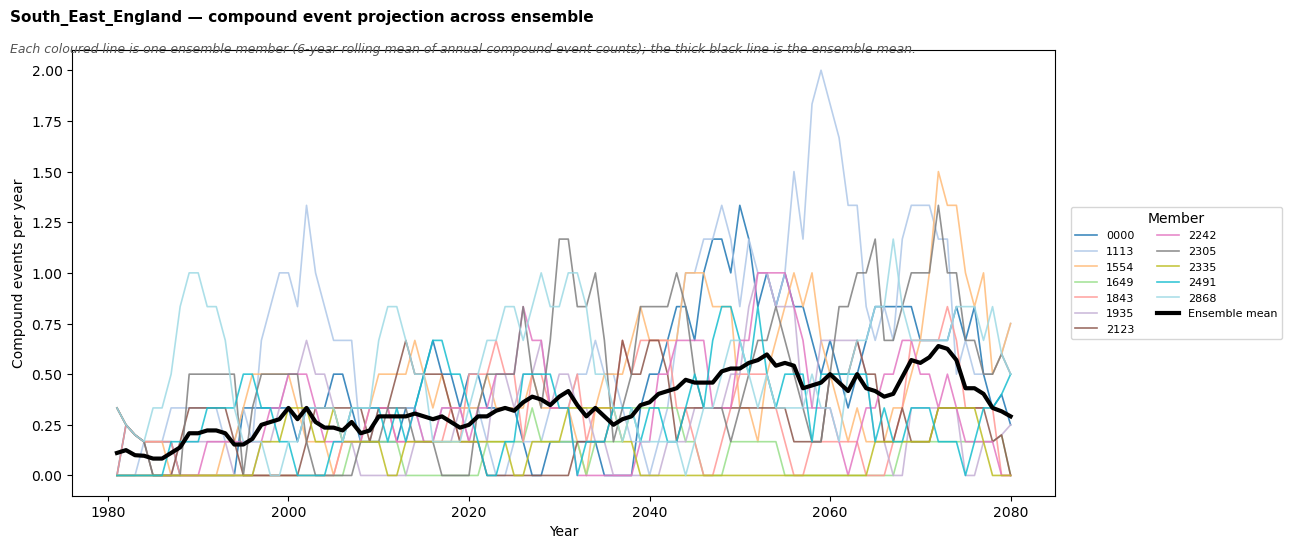

In [55]:
summary = summarise_ensemble_events(events_by_member)

# Each ensemble member is its own coloured line; the ensemble mean is the
# thick black line over them.
fig = plot_ensemble_spread(
    events_by_member,
    rolling_window=ROLLING_WINDOW,
    title=f'{REGION} — compound event projection across ensemble')

save_figure(fig, f'{FIGURES_DIR}/{REGION}_ensemble_spread.png')
plt.show()


## Step 4: Hovmoller - every member over time

Two figures: **number of events** per member per year, and **total extreme days** per member
per year. Members are ordered by total event count, so a trend appearing in only a few members
is still visible rather than being averaged away.


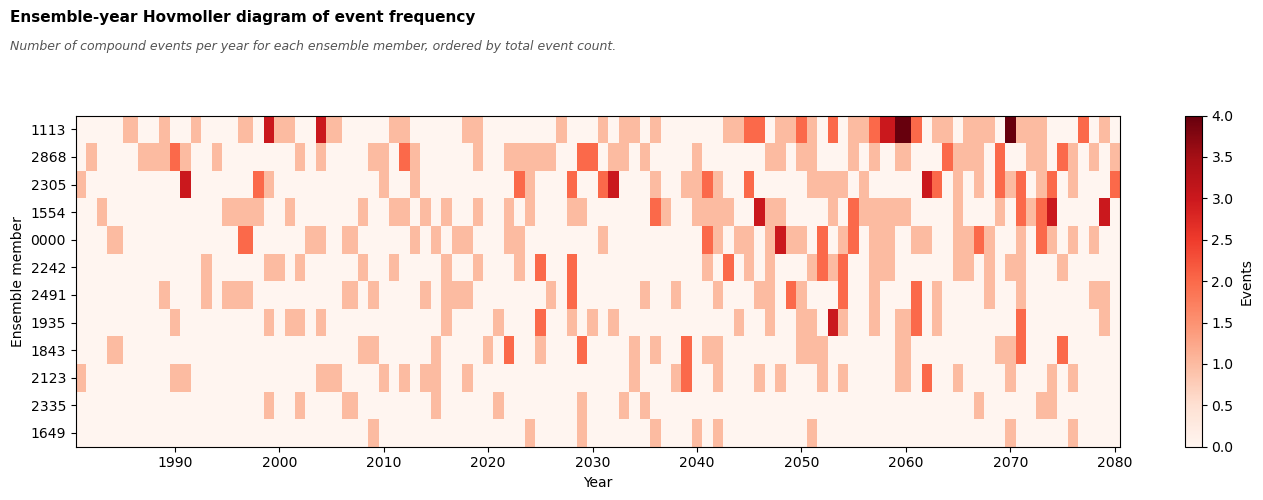

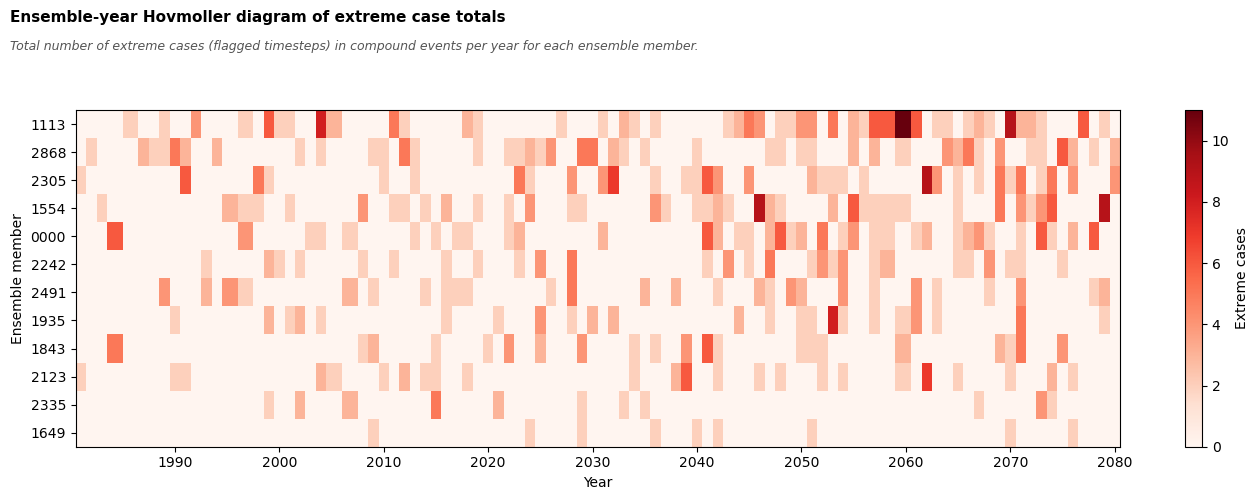

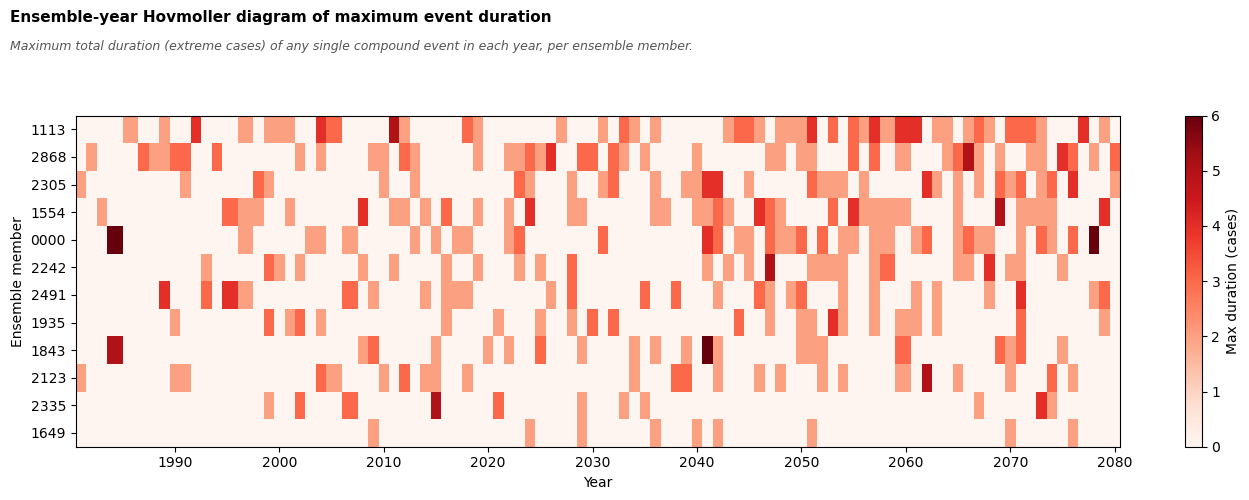

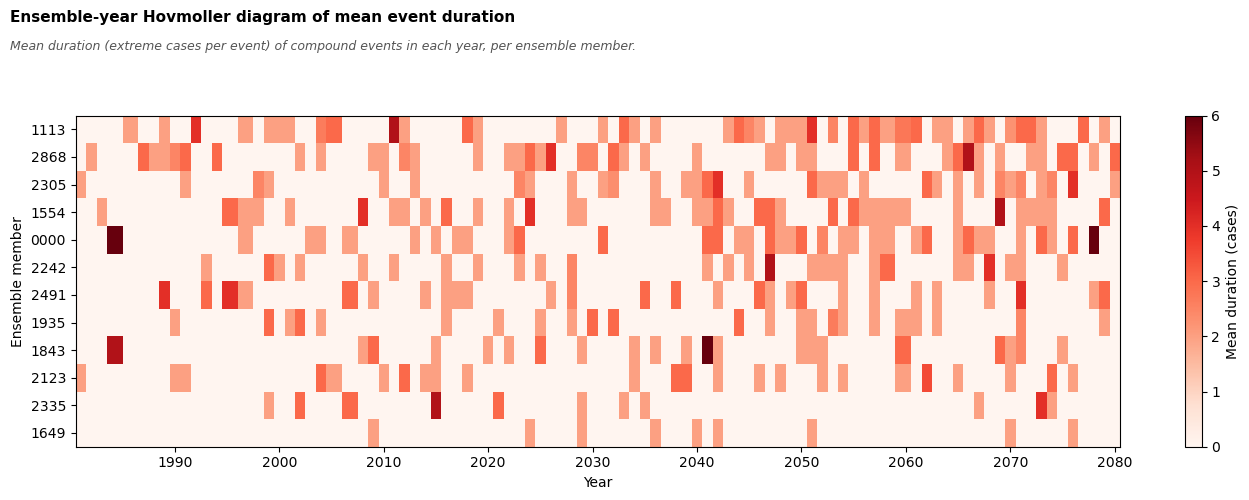

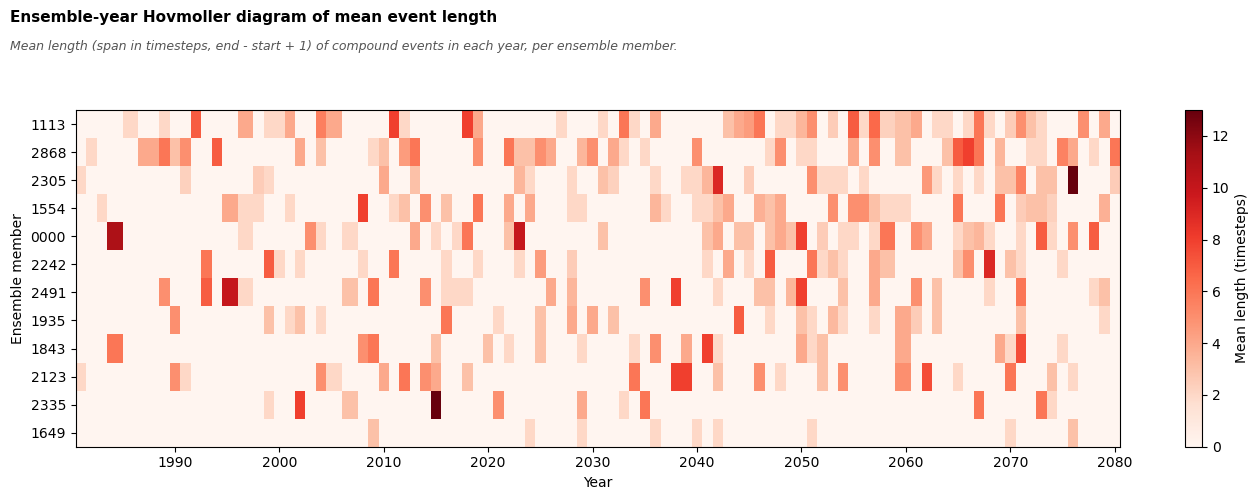

In [58]:
hov = plot_ensemble_hovmoller(
    all_events,
    ensemble_col='ensemble',
    year_col='year',
    duration_col='n_extreme_cases',
    length_col='length',
    cmap=CMAP,)

for name, fig in hov.items():
    save_figure(fig, f'{FIGURES_DIR}/{REGION}_hovmoller_{name}.png')
plt.show()


## Step 5: All regions

The next cell loads every region for every member **once** and caches the result. Both Step 5
and Step 6 read from that cache, so the data is not loaded twice.

This is the slowest cell in the notebook: it reads
`len(ALL_REGIONS) x len(ENSEMBLES)` files. Re-run the later cells freely without re-running this one.


In [59]:
uk_events_by_member = {}
uk_years = uk_months = None      # calendar axes, shared by all regions

for ensemble in ENSEMBLES:
    compound_idx_union = set()

    for region in ALL_REGIONS:
        try:
            region_data, r_years, r_months = load_region_ensemble(
                base_dir=BASE_DIR, region=region,
                ensembles=[ensemble],
                season_start=SEASON_START, season_length=SEASON_LENGTH,
                filename_pattern=FILENAME_PATTERN,
                return_time=True,
            )[ensemble]
            if uk_years is None:
                uk_years, uk_months = r_years, r_months

            binary_1 = flag_extreme_events(
                region_data, threshold=THRESHOLD_1, direction=DIRECTION_1,
                N=N_CONSECUTIVE_1, min_days=MIN_DAYS_1)

            if THRESHOLD_2 is not None:
                if BASE_DIR_2 is not None or FILENAME_PATTERN_2 is not None:
                    region_data_2 = load_region_ensemble(
                        base_dir=BASE_DIR_2 or BASE_DIR, region=region,
                        ensembles=[ensemble],
                        season_start=SEASON_START, season_length=SEASON_LENGTH,
                        filename_pattern=FILENAME_PATTERN_2 or FILENAME_PATTERN,
                        return_time=True,
                    ).get(ensemble, (region_data, r_years, r_months))[0]
                else:
                    region_data_2 = region_data

                binary_2 = flag_extreme_events(
                    region_data_2, threshold=THRESHOLD_2, direction=DIRECTION_2,
                    N=N_CONSECUTIVE_2, min_days=MIN_DAYS_2)
                if COMPOUND_MODE == 'co-occurring':
                    region_events = detect_compound_events_coincident(
                        binary_1, binary_2, delT=DELT, tau=TAU,
                        min_duration=MIN_DURATION,
                        years=r_years, months=r_months,
                        season_start=SEASON_START, season_length=SEASON_LENGTH)
                else:
                    region_events = detect_compound_events_bivariate(
                        binary_1, binary_2, delT=DELT, tau=TAU,
                        min_duration_1=MIN_DURATION_1,
                        min_duration_2=MIN_DURATION_2,
                        years=r_years, months=r_months,
                        season_start=SEASON_START, season_length=SEASON_LENGTH)
            else:
                region_events = detect_compound_events(
                    binary_1, delT=DELT, tau=TAU, min_duration=MIN_DURATION,
                    years=r_years, months=r_months,
                    season_start=SEASON_START, season_length=SEASON_LENGTH)

            # a UK-wide compound day = any region's compound-event day
            for _, row in region_events.iterrows():
                compound_idx_union.update(
                    range(int(row['start_idx']), int(row['end_idx']) + 1))
        except Exception as e:
            print(f"  skip {region} / {ensemble}: {e}")

    if uk_years is None:
        continue
    n_days = len(uk_years)
    union_compound_binary = np.zeros(n_days, dtype=int)
    for idx in compound_idx_union:
        if idx < n_days:
            union_compound_binary[idx] = 1

    # re-detect on the UK-wide union series (same season blocking!)
    events = detect_compound_events(
        union_compound_binary, delT=DELT, tau=TAU, min_duration=MIN_DURATION,
        years=uk_years, months=uk_months,
        season_start=SEASON_START, season_length=SEASON_LENGTH)

    if len(events) > 0:
        syear = season_year_labels(uk_years, uk_months, SEASON_START)
        events['year'] = syear[events['start_idx'].values]
        events['ensemble'] = ensemble
    uk_events_by_member[ensemble] = events
    print(f"  {ensemble}: {len(events)} UK-wide compound events")

uk_all_events = pd.concat(
    [df for df in uk_events_by_member.values() if len(df) > 0],
    ignore_index=True)
print(f"\nTotal UK-wide compound events: {len(uk_all_events)}")


  0000: 177 UK-wide compound events
  1113: 230 UK-wide compound events
  1554: 197 UK-wide compound events
  1649: 77 UK-wide compound events
  1843: 121 UK-wide compound events
  1935: 160 UK-wide compound events
  2123: 165 UK-wide compound events
  2242: 188 UK-wide compound events
  2305: 226 UK-wide compound events
  2335: 68 UK-wide compound events
  2491: 206 UK-wide compound events
  2868: 257 UK-wide compound events

Total UK-wide compound events: 2072


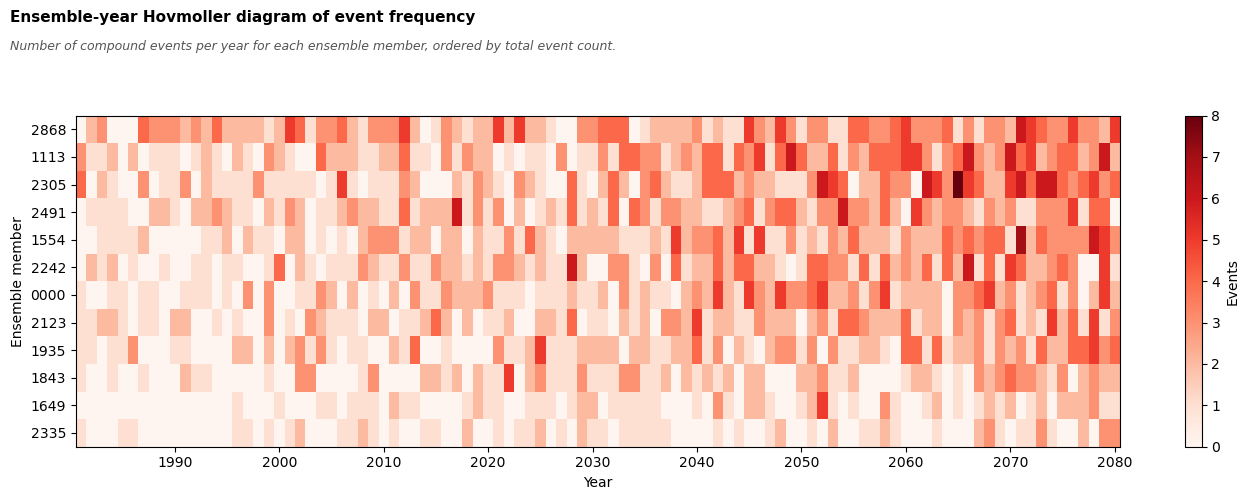

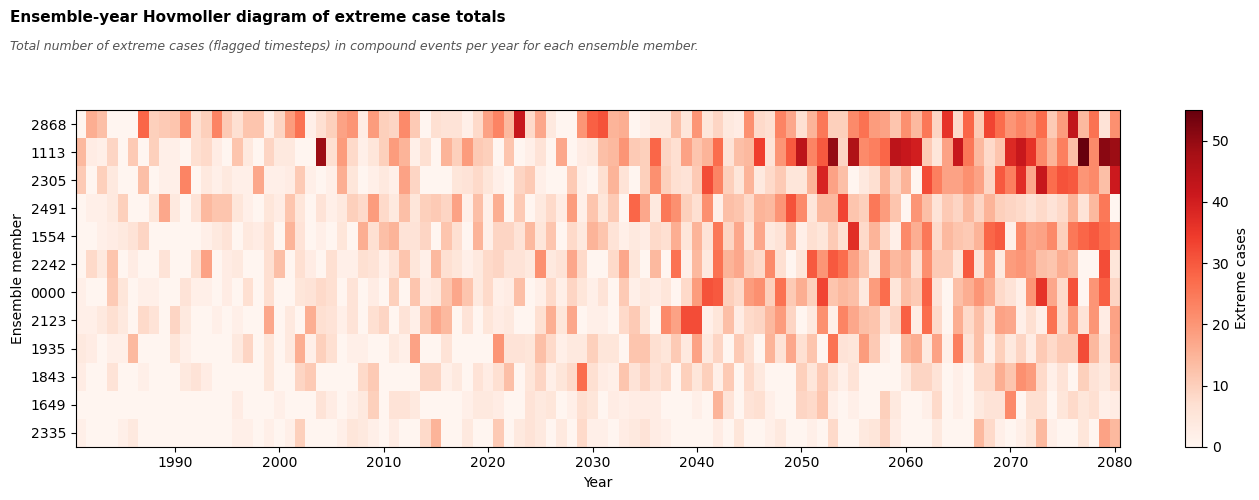

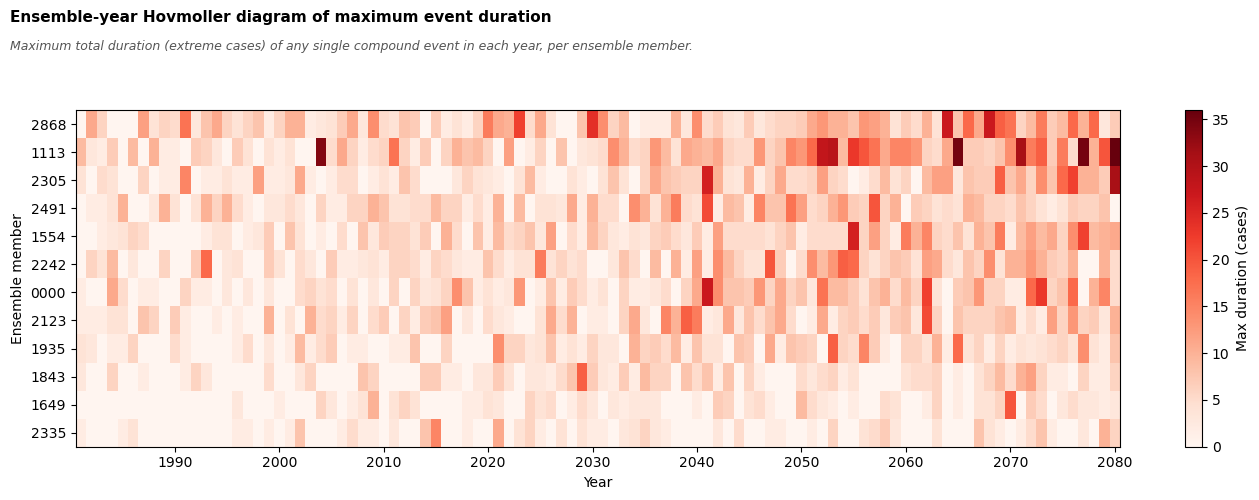

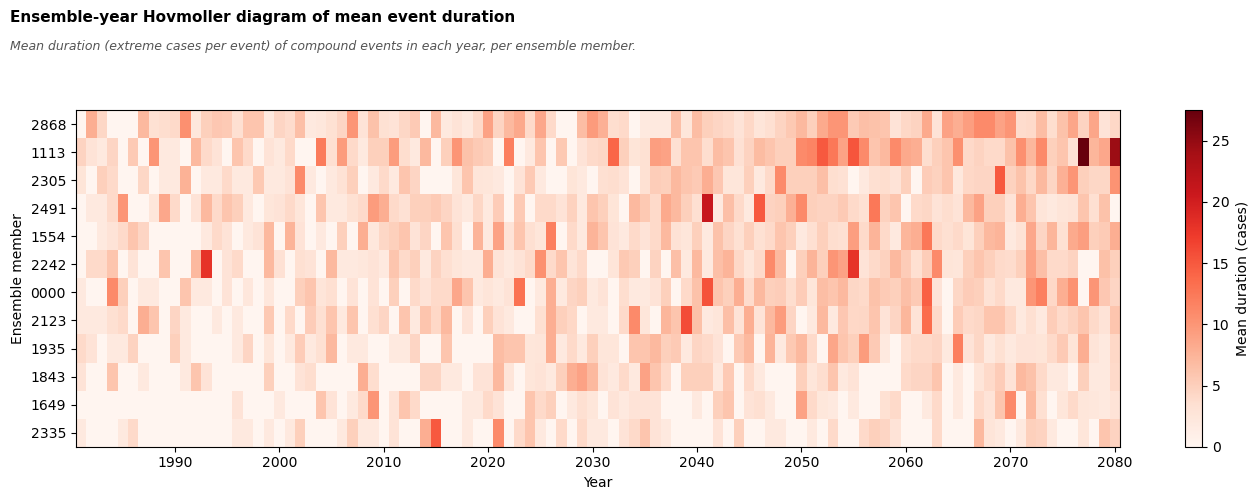

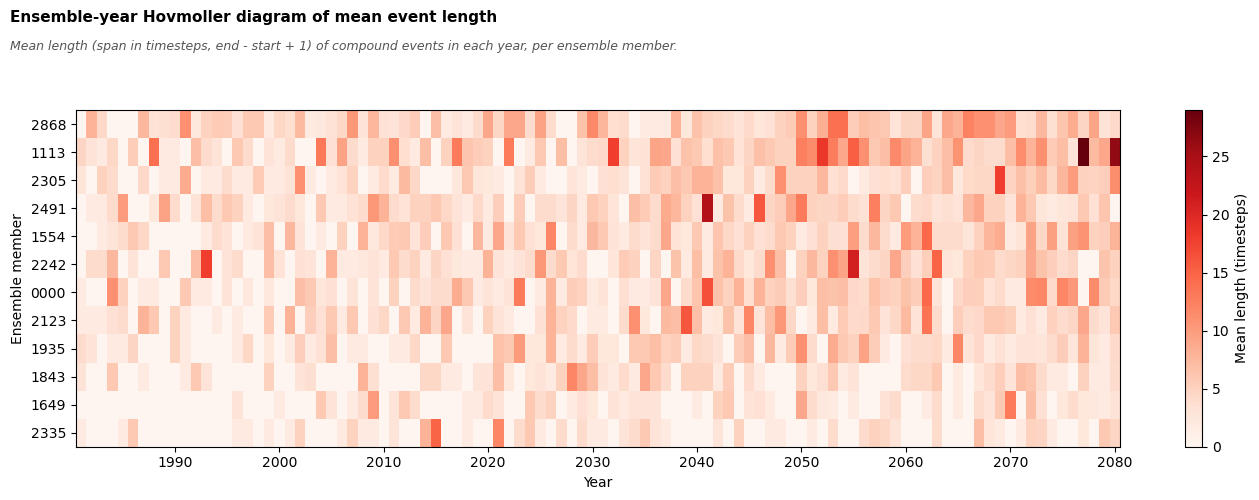

In [61]:
uk_hov = plot_ensemble_hovmoller(
    uk_all_events,
    ensemble_col='ensemble',
    year_col='year',
    duration_col='n_extreme_cases',
    length_col='length',
    cmap=CMAP,)
for name, fig in uk_hov.items():
    save_figure(fig, f'{FIGURES_DIR}/UK_wide_hovmoller_{name}.png')
plt.show()


## Step 6: Regional comparison

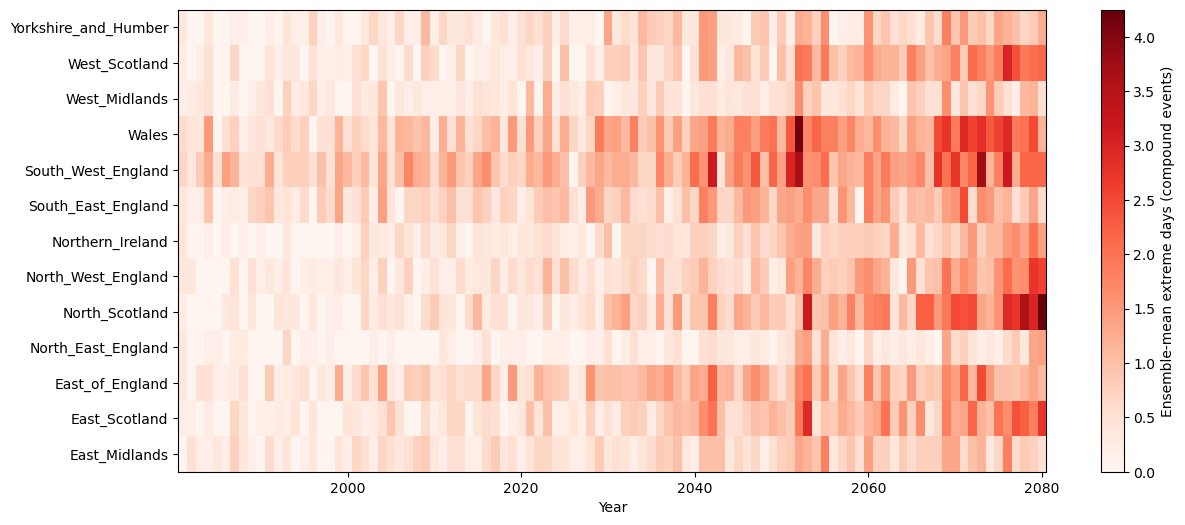

In [63]:
# For each region, compute ensemble-mean extreme days in compound events per year
region_year_matrix = {}

for region in ALL_REGIONS:
    member_counts = {}
    for ensemble in ENSEMBLES:
        try:
            data, yrs, mons = load_region_ensemble(
                base_dir=BASE_DIR, region=region, ensembles=[ensemble],
                season_start=SEASON_START, season_length=SEASON_LENGTH,
                filename_pattern=FILENAME_PATTERN, return_time=True,
            )[ensemble]
            binary = flag_extreme_events(
                data, threshold=THRESHOLD_1, direction=DIRECTION_1,
                N=N_CONSECUTIVE_1, min_days=MIN_DAYS_1)
            ev = detect_compound_events(
                binary, delT=DELT, tau=TAU, min_duration=MIN_DURATION,
                years=yrs, months=mons,
                season_start=SEASON_START, season_length=SEASON_LENGTH)
            if len(ev) > 0:
                syear = season_year_labels(yrs, mons, SEASON_START)
                ev['year'] = syear[ev['start_idx'].values]
                member_counts[ensemble] = ev.groupby('year')['n_extreme_cases'].sum()
        except Exception as e:
            print(f"  skip {region} / {ensemble}: {e}")
    if member_counts:
        region_year_matrix[region] = pd.DataFrame(member_counts).fillna(0).mean(axis=1)

region_df = pd.DataFrame(region_year_matrix).T.fillna(0)   # regions x years

fig, ax = plt.subplots(figsize=(14, 6))
c = ax.pcolormesh(region_df.columns, np.arange(len(region_df)), region_df.values,
                  shading='nearest', cmap=CMAP)
ax.set_yticks(np.arange(len(region_df)))
ax.set_yticklabels(region_df.index)
ax.set_xlabel('Year')
fig.colorbar(c, ax=ax, label='Ensemble-mean extreme days (compound events)')
save_figure(fig, f'{FIGURES_DIR}/regional_hovmoller.png')
plt.show()


# step 7: MSLP composite at compouind-event onset

The mean sea level pressure anomaly on the first day of each compound event, and on the days before it. Ensemble mean.   
Day 0 is the composite on `start_date`, which is the first flag of the event. If `FLAG_1 = 'last` with N>1 that is the day the first spell ended, so day0 is N-1 days after the star. If you run `onset_lag(FLAG_1, n_CONSECUTIVE_1)` retuns the correction, which is applied automatically. 

Lags are applied as real dates (so for UKCP18, the 360 day calendar is adjusted so that the day before 1 June is May 30)

In [69]:
# Step 7 runs only if MSLP_BASE_DIR is set in the parameter cell.
if MSLP_BASE_DIR is None:
    print("MSLP_BASE_DIR is None — skipping Step 7. Set it to run composites.")
else:
    # 1. Load the composite field on the FULL year (no season extraction)
    mslp_by_member, (mslp_lats, mslp_lons) = load_field_ensemble(
        base_dir=MSLP_BASE_DIR, ensembles=ENSEMBLES,
        filename_pattern=MSLP_PATTERN, region=MSLP_REGION)

    # 2. Attach real dates to each member's events, using the time coordinate
    #    of the series the events were DETECTED on
    events_dated = {}
    for ens, df in events_by_member.items():
        if len(df) == 0 or ens not in ensemble_data:
            continue
        det_dates = ensemble_data[ens][3]     # the detection series' own dates
        events_dated[ens] = attach_event_dates(df, det_dates)

    # 3. Correct the anchor if the flagging put it at the END of a spell
    shift = onset_lag(FLAG_1, N_CONSECUTIVE_1)
    lags = tuple(l + shift for l in COMPOSITE_LAGS)
    if shift:
        print(f"FLAG_1='{FLAG_1}' with N={N_CONSECUTIVE_1}: shifting lags by "
              f"{shift} so day 0 is the true onset -> {lags}")

    # 4. Composite at each lag
    composites = composite_lag_sequence(
        mslp_by_member, events_dated, lags=lags,
        baseline_years=COMPOSITE_BASELINE, units=COMPOSITE_UNITS)

    for lag, res in composites.items():
        print(res)
    display(composites[lags[-1]].summary())

    # 5. Plot each lag panel side by side
    n_lags = len(lags)
    fig, axes = plt.subplots(1, n_lags, figsize=(5 * n_lags, 5),
                             subplot_kw={'aspect': 'equal'})
    if n_lags == 1:
        axes = [axes]

    vmax = max(np.nanmax(np.abs(res.composite)) for res in composites.values())
    vmax = vmax if vmax > 0 else 1.0

    for ax, (lag, res) in zip(axes, composites.items()):
        cf = ax.contourf(mslp_lons, mslp_lats, res.composite,
                         levels=20, cmap='RdBu_r', vmin=-vmax, vmax=vmax)
        ax.set_title(f'Lag {lag:+d} d  (n={res.n_events})')
        ax.set_xlabel('Longitude')
        if ax is axes[0]:
            ax.set_ylabel('Latitude')
        plt.colorbar(cf, ax=ax, label=COMPOSITE_UNITS, shrink=0.8)

        # hatch where >= COMPOSITE_AGREEMENT fraction of members agree on sign
        if COMPOSITE_AGREEMENT is not None:
            mask = res.member_agreement >= COMPOSITE_AGREEMENT
            ax.contourf(mslp_lons, mslp_lats, mask.astype(float),
                        levels=[0.5, 1.5], hatches=['//'], colors='none')

    fig.suptitle(f'{REGION} — MSLP anomaly composite ({COMPOSITE_UNITS})',
                 fontsize=12)
    plt.tight_layout()
    save_figure(fig, f'{FIGURES_DIR}/{REGION}_mslp_composite_lags.png')
    plt.show()


KeyError: 'decade_range'

---

# Extending the detector

Everything above is demostration. The code is in `threshold_detector/`, so any piece can
be swapped without touching the notebook.

### Where things live

| File | Contains |
|---|---|
| `detector.py` | Flagging, compound detection, segmentation, aggregation |
| `plotting.py` | All figures. Every label is a keyword argument |
| `coincidence.py` | Event Coincidence Analysis wrappers (needs the ECA repo) |

### The two contracts

**1. A flagging function** takes a timeseries and returns a binary array of the same length,
where `1` marks an extreme day.

```python
binary = flag_extreme_events(data, threshold=20, N=1, direction='above')
```

Replace this to define "extreme" differently - a percentile
(`flag_extreme_events_percentile`), a rolling accumulation, a rate of change. Anything
returning a same-length binary array will work with everything downstream.

**2. A detection function** takes one or two binary arrays and returns one row per event:

| Column | Meaning |
|---|---|
| `start_idx`, `end_idx` | Event bounds, as positions in the input array (inclusive) |
| `length` | `end_idx - start_idx + 1`, the span in days |
| `n_extreme_days` | Extreme days the event actually contains |
| `n_extreme_days_1`, `n_extreme_days_2` | Per-variable counts (bivariate, sequential) |
| `n_coincident_days` | Days where both were extreme (co-occurring) |
| `n_sequential_days` | Trigger days (sequential) |
| `year`, `ensemble` | Added by this notebook, not the detector |
| `n_regions`, `regions` | Added by `detect_multiregion_events` |

Anything returning `start_idx`, `end_idx`, `length` and `n_extreme_days` will plot correctly.

### If you write your own detector

- **Wrap it in `detect_by_segment`** so it cannot merge events across a seasonal gap.
- **Return indices, not dates.** The notebook converts indices to years using the file's own
  time coordinate; returning dates directly would bypass that.
- **Return an empty DataFrame with the right columns** when nothing is found, so downstream
  cells do not raise on a missing column.

### Getting at the data directly

Every intermediate object is a plain numpy array or pandas DataFrame:

```python
all_events                    # every event, chosen region, all members
uk_all_events                 # UK-wide events, with n_regions and regions
events_by_member['0000']      # one member
region_results[('Wales','0000')]['mask']    # daily binary mask
summary                       # per-year mean/min/max across the ensemble

all_events.to_csv('events.csv', index=False)
long_events = all_events[all_events['length'] >= 20]
```

---

# Assumptions and things to watch

| Watch out for | Why | What to do |
|---|---|---|
| **`MIN_DURATION` vs `MIN_TRIGGER_DAYS`** | In single-variable and co-occurring modes, `MIN_DURATION` counts extreme days. In sequential mode the filter is `MIN_TRIGGER_DAYS`, counting **trigger days** - and triggers are rare, so most real events have exactly one. | Leave `MIN_TRIGGER_DAYS = 1`. To keep only long events, filter on `length` instead. The detector warns if the setting discards everything. |
| **`DELT` does two jobs** | Within a region it merges nearby extreme days. In Step 5 it also decides how many days apart two *regions* can be and still count as one UK episode. | Raising `DELT` widens events and makes UK-wide events more likely. |
| **Seasons are kept apart** | JJAS years sit next to each other in the array; without the guard, September and the following June would merge. | Handled automatically. Preserve it in any custom detector by using `detect_by_segment`. |
| **Events are labelled by their START year** | An event spanning a year boundary counts once, in the year it began. Within a single season this cannot happen. | Only relevant if you set `LOWER_MONTH`/`HIGHER_MONTH` to span a new year, such as winter months. |
| **Ensemble means hide variability** | Step 6 uses a mean for regional comparison. It will look calmer than any individual member. | Judge uncertainty from Steps 3 and 4, not Step 6. |
| **Failed loads are skipped, not fatal** | A missing file prints a warning and continues, so a partial ensemble can silently look like a real result. | Check the loaded/failed counts printed by Steps 1 and 5. |

### If you get no events or the data looks funny

Work down in this order:

1. **Is anything flagged as extreme at all?** Check the threshold direction and value against your data's units.
2. **Is `N_CONSECUTIVE` too strict?** Requiring many consecutive days is far more demanding than it appears.
3. **Is the duration filter too strict?** `MIN_DURATION` in single/co-occurring mode; `MIN_TRIGGER_DAYS` in sequential.
4. **Sequential only: is `TAU` too short?** Variable 2 must follow Variable 1 within `TAU` days.
5. **Step 5 only: is `MIN_REGIONS` too high?** Set it to 1 to check whether regional events exist at all.
